<a href="https://colab.research.google.com/github/KasunUdayanga/NER-Sinhala-political-comment-identifier/blob/main/Notebooks/xlm_roberta_large.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')
file_path = '/content/drive/MyDrive/ColabNotebooks/sinhala_dataset_balanced.conll'



def parse_conll_data(file_path):
    data = []
    with open(file_path, 'r', encoding='utf-8') as f:
        tokens = []
        labels = []
        for line in f:
            line = line.strip()
            if line:
                parts = line.split()
                # Assuming CoNLL format where token is first part and label is last part
                if len(parts) >= 2:
                    tokens.append(parts[0])
                    labels.append(parts[-1]) # Take the last part as the label
            else:
                if tokens:
                    data.append({'tokens': tokens, 'labels': labels})
                    tokens = []
                    labels = []
        if tokens: # Add the last sentence if the file does not end with an empty line
            data.append({'tokens': tokens, 'labels': labels})
    return data

# Load the CoNLL data
conll_data = parse_conll_data(file_path)

unique_tags = set()

for entry in conll_data:
    for label in entry['labels']:
        unique_tags.add(label)

# Convert set to a sorted list to ensure consistent ID assignment
sorted_unique_tags = sorted(list(unique_tags))

# Create tag_to_id mapping
tag_to_id = {tag: i for i, tag in enumerate(sorted_unique_tags)}

# Create id_to_tag mapping
id_to_tag = {i: tag for i, tag in enumerate(sorted_unique_tags)}

print(f"Total unique NER tags found: {len(unique_tags)}")
print("\nTag to ID mapping:")
print(tag_to_id)
print("\nID to Tag mapping:")
print(id_to_tag)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Total unique NER tags found: 9

Tag to ID mapping:
{'B-LOC': 0, 'B-ORG': 1, 'B-Other': 2, 'B-PER': 3, 'I-LOC': 4, 'I-ORG': 5, 'I-Other': 6, 'I-PER': 7, 'O': 8}

ID to Tag mapping:
{0: 'B-LOC', 1: 'B-ORG', 2: 'B-Other', 3: 'B-PER', 4: 'I-LOC', 5: 'I-ORG', 6: 'I-Other', 7: 'I-PER', 8: 'O'}


In [4]:
from transformers import AutoTokenizer

# 2. Initialize a tokenizer
model_name = "xlm-roberta-large"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_and_align_labels(tokens, labels, tokenizer, tag_to_id):
    # 4. Tokenize the tokens
    tokenized_inputs = tokenizer(tokens, is_split_into_words=True, truncation=True)

    # 5. Get the word_ids
    word_ids = tokenized_inputs.word_ids()

    aligned_labels = []
    previous_word_idx = None
    for word_idx in word_ids:
        if word_idx is None: # 7.1. Special tokens or padding
            aligned_labels.append(-100)
        elif word_idx != previous_word_idx: # 7.2. First subword token of an original word
            # Get the label for the current original word
            original_label = labels[word_idx]
            aligned_labels.append(tag_to_id[original_label])
        else: # 7.3. Subsequent subword token of the same original word
            aligned_labels.append(-100)
        previous_word_idx = word_idx

    tokenized_inputs["labels"] = aligned_labels
    tokenized_inputs["decoded_tokens"] = tokenizer.convert_ids_to_tokens(tokenized_inputs['input_ids']) # Add decoded tokens
    return tokenized_inputs

tokenized_and_aligned_data = []
print(f"Tokenizing and aligning labels for {len(conll_data)} sentences...")
for i, entry in enumerate(conll_data):
    tokenized_output = tokenize_and_align_labels(entry['tokens'], entry['labels'], tokenizer, tag_to_id)
    tokenized_and_aligned_data.append(tokenized_output)
    if i < 5: # Print first 5 for sample
        print(f"\nSample sentence {i+1}:")
        print(f"  Original Tokens: {entry['tokens']}")
        print(f"  Original Labels: {entry['labels']}")
        print(f"  Input IDs: {tokenized_output['input_ids']}")
        print(f"  Aligned Labels: {tokenized_output['labels']}")
        print(f"  Decoded Tokens: {tokenized_output['decoded_tokens']}")

if len(conll_data) > 5:
    print(f"\n... and {len(conll_data) - 5} more tokenized and aligned sentences.")

print(f"Finished tokenizing and aligning labels for {len(tokenized_and_aligned_data)} sentences.")

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

Tokenizing and aligning labels for 9633 sentences...

Sample sentence 1:
  Original Tokens: ['පාලමුන']
  Original Labels: ['B-LOC']
  Input IDs: [0, 237394, 80078, 2]
  Aligned Labels: [-100, 0, -100, -100]
  Decoded Tokens: ['<s>', '▁පාලම', 'ුන', '</s>']

Sample sentence 2:
  Original Tokens: ['ඔබතමයි', 'කාරයෝන්ට', 'රාජපක්ෂලාටම්', 'හර්ශ', 'විපක්ශයට', 'අවලද', 'දැම්මාඇත්ත', 'ඩොබිලාට', 'පැන්චො']
  Original Labels: ['B-Other', 'B-Other', 'B-PER', 'B-PER', 'B-ORG', 'B-Other', 'B-Other', 'B-Other', 'B-Other']
  Input IDs: [0, 11838, 84263, 2009, 6, 25444, 19687, 24625, 52374, 3998, 722, 4490, 14235, 68725, 210630, 27436, 6733, 28264, 2885, 1859, 225608, 72980, 30498, 6, 146221, 49485, 3998, 722, 19853, 2148, 29057, 25859, 2]
  Aligned Labels: [-100, 2, -100, -100, 2, -100, -100, -100, 3, -100, -100, -100, 3, -100, 1, -100, -100, 2, -100, -100, 2, -100, -100, 2, -100, -100, -100, -100, 2, -100, -100, -100, -100]
  Decoded Tokens: ['<s>', '▁ඔබ', 'තම', 'යි', '▁', 'කාර', 'යෝ', 'න්ට', '▁රාජපක්ෂ'

## Split Data into Train and Test Sets

### Subtask:
Divide the `tokenized_and_aligned_data` into training and testing sets to evaluate the model's generalization capabilities. A typical split would be 80% for training and 20% for testing.


In [5]:
from sklearn.model_selection import train_test_split

In [6]:
train_data, test_data = train_test_split(tokenized_and_aligned_data, test_size=0.2, random_state=42)

print(f"Number of samples in training set: {len(train_data)}")
print(f"Number of samples in testing set: {len(test_data)}")

Number of samples in training set: 7706
Number of samples in testing set: 1927


In [7]:
import torch
from torch.utils.data import Dataset, DataLoader

**Reasoning**:
I need to define a custom PyTorch Dataset class to properly handle the tokenized and aligned data for training, as instructed by the subtask.



In [8]:
class NERDataset(Dataset):
    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        entry = self.data[idx]
        return {
            'input_ids': torch.tensor(entry['input_ids'], dtype=torch.long),
            'attention_mask': torch.tensor(entry['attention_mask'], dtype=torch.long),
            'labels': torch.tensor(entry['labels'], dtype=torch.long)
        }

print("Defined custom NERDataset class.")

Defined custom NERDataset class.


**Reasoning**:
Now that the custom `NERDataset` class is defined, I need to create instances of this dataset for both the training and testing data, and then initialize `DataLoader` instances for each, setting the appropriate batch size and shuffling for training, as per the subtask instructions.



## Load XLM-RoBERTa Model for Token Classification

### Subtask:
Load the pre-trained `xlm-roberta-large` model with a token classification head, specifically `XLMRobertaForTokenClassification`. The model should be initialized with the number of unique NER tags (num_labels) identified earlier.


In [9]:
from transformers import XLMRobertaForTokenClassification

# Determine the number of unique NER tags
num_labels = len(id_to_tag)

# Load the pre-trained XLMRobertaForTokenClassification model
model = XLMRobertaForTokenClassification.from_pretrained(model_name, num_labels=num_labels)

print(f"Loaded {model_name} model with {num_labels} labels for token classification.")
print(f"Model configuration: {model.config}")

model.safetensors:   0%|          | 0.00/2.24G [00:00<?, ?B/s]

Some weights of XLMRobertaForTokenClassification were not initialized from the model checkpoint at xlm-roberta-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Loaded xlm-roberta-large model with 9 labels for token classification.
Model configuration: XLMRobertaConfig {
  "architectures": [
    "XLMRobertaForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "bos_token_id": 0,
  "classifier_dropout": null,
  "dtype": "float32",
  "eos_token_id": 2,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 1024,
  "id2label": {
    "0": "LABEL_0",
    "1": "LABEL_1",
    "2": "LABEL_2",
    "3": "LABEL_3",
    "4": "LABEL_4",
    "5": "LABEL_5",
    "6": "LABEL_6",
    "7": "LABEL_7",
    "8": "LABEL_8"
  },
  "initializer_range": 0.02,
  "intermediate_size": 4096,
  "label2id": {
    "LABEL_0": 0,
    "LABEL_1": 1,
    "LABEL_2": 2,
    "LABEL_3": 3,
    "LABEL_4": 4,
    "LABEL_5": 5,
    "LABEL_6": 6,
    "LABEL_7": 7,
    "LABEL_8": 8
  },
  "layer_norm_eps": 1e-05,
  "max_position_embeddings": 514,
  "model_type": "xlm-roberta",
  "num_attention_heads": 16,
  "num_hidden_layers": 24,
  "output_past": true,
  "pad_token_i

**Reasoning**:
The previous execution produced a warning about uninitialized weights in the classifier head, which is expected behavior when loading a pre-trained model for a new token classification task. The code itself is correct and performs the requested action of loading the model with the specified number of labels. No code changes are required to address this warning.



In [12]:
!pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.8 MB/s eta 0:00:00


**Reasoning**:
The `evaluate` library has been successfully installed. Now, I can proceed with importing it along with `numpy` and loading the `seqeval` metric, as originally intended in the subtask instructions.



In [13]:
!pip install seqeval

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for seqeval: filename=seqeval-1.2.2-py3-none-any.whl size=16162 sha256=e1d1ebe6776adaf26a385e970b44b86c3eb7c8f0623598c9b7403aa491e81ebb
  Stored in directory: /root/.cache/pip/wheels/5f/b8/73/0b2c1a76b701a677653dd79ece07cfabd7457989dbfbdcd8d7
Successfully built seqeval


**Reasoning**:
Now that `seqeval` is installed, I will re-attempt to import `evaluate` and `numpy`, and then load the `seqeval` metric, as this was the original intent before encountering the import error.



In [14]:
import evaluate
import numpy as np

# Load the 'seqeval' metric
metric = evaluate.load('seqeval')

print("Imported 'evaluate' and 'numpy', and loaded 'seqeval' metric.")

Imported 'evaluate' and 'numpy', and loaded 'seqeval' metric.


**Reasoning**:
Now that the necessary libraries and metric are loaded, I need to define the `compute_metrics` function as instructed, which will take model predictions and true labels, process them to remove padding, and then compute and return the NER evaluation metrics using `seqeval`.



In [16]:
def compute_metrics(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)

    # Filter out ignored labels (-100) and convert IDs to string labels
    true_predictions = [
        [id_to_tag[int(pred_id)] for (pred_id, true_label_id) in zip(prediction_ids, label_ids) if true_label_id != -100]
        for prediction_ids, label_ids in zip(predictions, labels)
    ]
    true_labels = [
        [id_to_tag[int(true_label_id)] for (pred_id, true_label_id) in zip(prediction_ids, label_ids) if true_label_id != -100]
        for prediction_ids, label_ids in zip(predictions, labels)
    ]

    # Compute overall and tag-wise metrics using seqeval
    results = metric.compute(predictions=true_predictions, references=true_labels)

    # Extract tag-wise F1 scores
    # The 'results' dictionary from seqeval.compute contains overall metrics and dicts for each label.
    # We iterate through the results and extract 'f1' from each tag's dictionary.
    tag_f1_scores = {f"{tag}_f1": metrics_dict["f1"] for tag, metrics_dict in results.items() if isinstance(metrics_dict, dict) and "f1" in metrics_dict}

    # Combine overall metrics with tag-wise F1 scores
    return {
        "precision": results["overall_precision"],
        "recall": results["overall_recall"],
        "f1": results["overall_f1"],
        "accuracy": results["overall_accuracy"],
        **tag_f1_scores
    }
print("Defined compute_metrics function.")

Defined compute_metrics function.
{0: 'B-LOC', 1: 'B-ORG', 2: 'B-Other', 3: 'B-PER', 4: 'I-LOC', 5: 'I-ORG', 6: 'I-Other', 7: 'I-PER', 8: 'O'}


**Reasoning**:
Now that the `Trainer` class is imported, I need to initialize a `Trainer` object with the model, training arguments, datasets, and evaluation metrics function, and then start the fine-tuning process as per the subtask instructions.



In [ ]:
class NERDataset(Dataset):
    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        entry = self.data[idx]
        return {
            'input_ids': entry['input_ids'],
            'attention_mask': entry['attention_mask'],
            'labels': entry['labels']
        }

print("Defined custom NERDataset class to return raw lists for proper batching.")

Defined custom NERDataset class to return raw lists for proper batching.


**Reasoning**:
The `NERDataset` class has been redefined. I need to recreate the `train_dataset` and `test_dataset` instances using the corrected `NERDataset` definition, and then re-initialize the `DataLoader` objects to reflect these changes. This ensures that the `Trainer` will use the properly formatted data.



In [18]:
batch_size = 4

# Create Dataset objects with the corrected NERDataset class
train_dataset = NERDataset(train_data)
test_dataset = NERDataset(test_data)


print(f"Train Dataset size: {len(train_dataset)}")
print(f"Test Dataset size: {len(test_dataset)}")

Train Dataset size: 7706
Test Dataset size: 1927


In [21]:
from transformers import TrainingArguments
from transformers.trainer_utils import EvaluationStrategy

# Define training arguments
training_args = TrainingArguments(
    output_dir="./ner_model_output",  # Output directory for model checkpoints and logs
    eval_strategy="epoch",    # Evaluate every epoch
    learning_rate=2e-5,             # Learning rate
    per_device_train_batch_size=4, # Further reduced batch size per device during training
    per_device_eval_batch_size=4,  # Further reduced batch size per device during evaluation
    num_train_epochs=5,             # Total number of training epochs
    weight_decay=0.01,              # Strength of weight decay
    logging_dir='./logs',           # Directory for storing logs
    logging_steps=100,              # Log every 100 steps
    save_strategy="epoch",          # Save model checkpoint every epoch
    load_best_model_at_end=True,    # Load the best model at the end of training
    metric_for_best_model="f1",     # Metric to use to compare models (changed from "overall_f1" to "f1")
    push_to_hub=False               # Whether or not to push to the Hugging Face Model Hub
)

print("TrainingArguments initialized with further reduced batch size.")

TrainingArguments initialized with further reduced batch size.


**Reasoning**:
Now that the `TrainingArguments` have been updated with a further reduced batch size, I need to re-initialize the `Trainer` object with these new arguments and then restart the fine-tuning process. This should resolve the `OutOfMemoryError` encountered previously and allow the training to proceed as intended.



In [23]:
from transformers import DataCollatorForTokenClassification, Trainer

# Explicitly define the data collator
data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer, padding=True, label_pad_token_id=-100)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
    data_collator=data_collator # Pass the explicitly created data collator
)

print("Trainer initialized with further reduced batch size. Starting training...")
trainer.train()
print("Training completed.")

Trainer initialized with further reduced batch size. Starting training...


Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy,Loc F1,Org F1,Other F1,Per F1
1,0.383300,0.635047,0.864646,0.860213,0.862423,0.820072,0.855906,0.895647,0.867852,0.805808
2,0.238500,0.586260,0.891961,0.846566,0.868670,0.828811,0.877900,0.933413,0.868729,0.825165
3,0.232000,0.627602,0.883456,0.919626,0.901178,0.866225,0.888341,0.963235,0.902739,0.859949
4,0.175900,0.639350,0.894246,0.910428,0.902264,0.866739,0.910569,0.977695,0.901938,0.856635


Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy,Loc F1,Org F1,Other F1,Per F1
1,0.383300,0.635047,0.864646,0.860213,0.862423,0.820072,0.855906,0.895647,0.867852,0.805808
2,0.238500,0.586260,0.891961,0.846566,0.868670,0.828811,0.877900,0.933413,0.868729,0.825165
3,0.232000,0.627602,0.883456,0.919626,0.901178,0.866225,0.888341,0.963235,0.902739,0.859949
4,0.175900,0.639350,0.894246,0.910428,0.902264,0.866739,0.910569,0.977695,0.901938,0.856635
5,0.134900,0.686967,0.894936,0.910051,0.902430,0.866625,0.911235,0.978908,0.901665,0.859175


Training completed.


## Evaluate Model and Get Predictions

### Subtask:
After training, evaluate the model on the test set to obtain the final evaluation metrics and predictions. The predictions will be used to generate the confusion matrix.


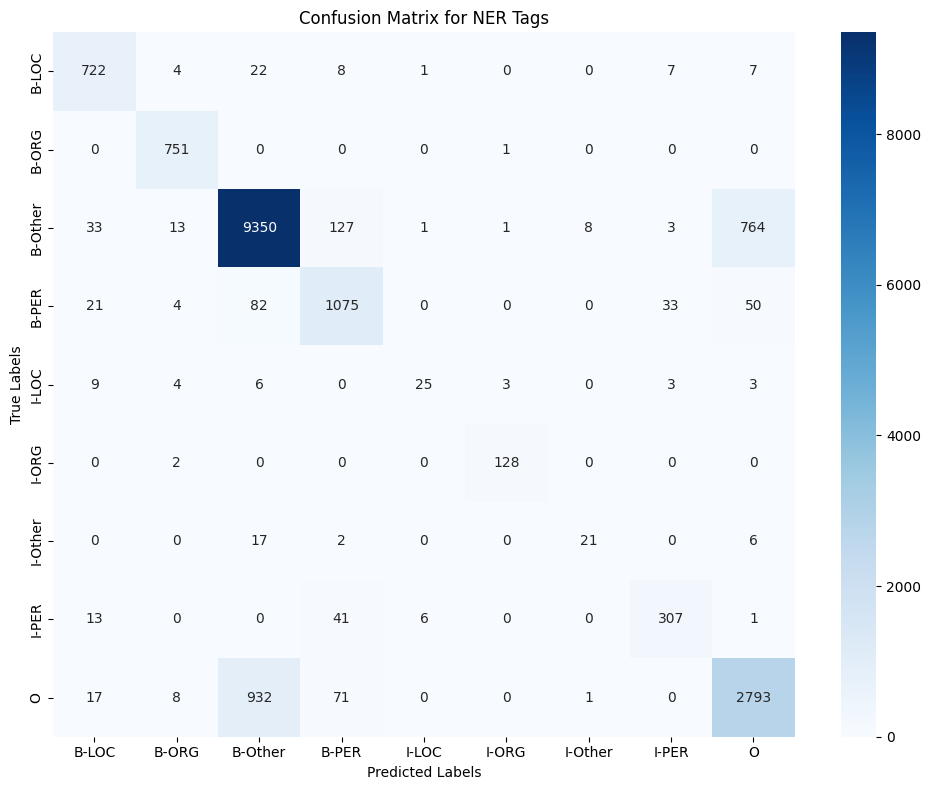

Confusion matrix generated and visualized.


In [25]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Get predictions from the trained model
predictions = trainer.predict(test_dataset)
raw_predictions = predictions.predictions
true_labels_ids = predictions.label_ids

predicted_labels_ids = np.argmax(raw_predictions, axis=2)

# Flatten true labels and predicted labels, filtering out -100 padding
true_labels_flat = []
predicted_labels_flat = []

for i in range(len(true_labels_ids)):
    for j in range(len(true_labels_ids[i])):
        if true_labels_ids[i][j] != -100:
            true_labels_flat.append(id_to_tag[true_labels_ids[i][j]])
            predicted_labels_flat.append(id_to_tag[predicted_labels_ids[i][j]])

# Generate the confusion matrix
cm = confusion_matrix(true_labels_flat, predicted_labels_flat, labels=list(id_to_tag.values()))

# Visualize the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=list(id_to_tag.values()), yticklabels=list(id_to_tag.values()))
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix for NER Tags')
plt.tight_layout()
plt.show()

print("Confusion matrix generated and visualized.")

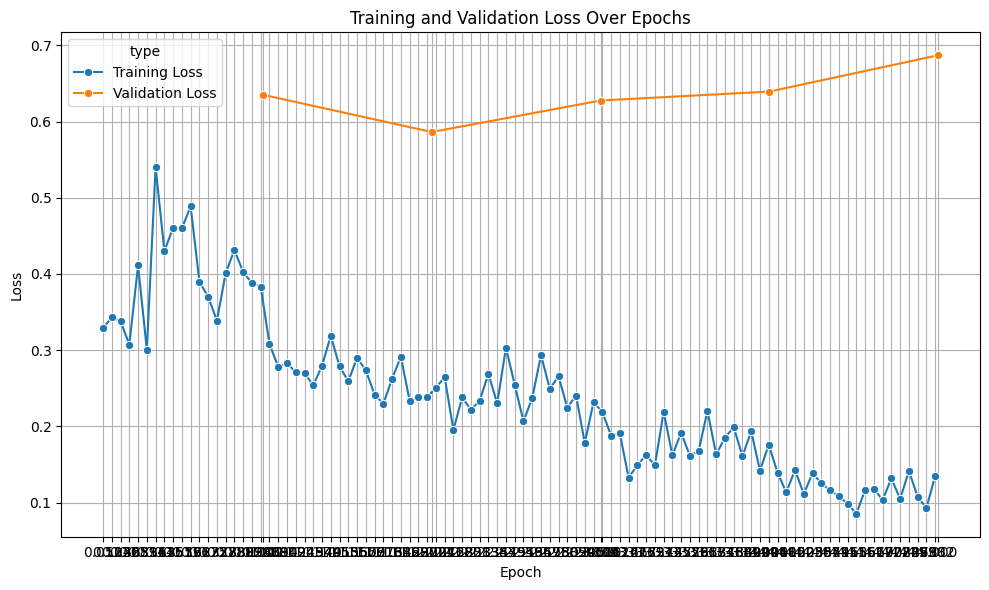

Chart showing training and validation loss generated.


In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Extract logging history from the trainer
log_history = trainer.state.log_history

# Filter out training and evaluation loss entries
train_losses = []
eval_losses = []
epochs = []

for log in log_history:
    if 'loss' in log and 'eval_loss' not in log: # Training loss entries
        train_losses.append({'epoch': log['epoch'], 'loss': log['loss'], 'type': 'Training Loss'})
    elif 'eval_loss' in log: # Evaluation loss entries
        eval_losses.append({'epoch': log['epoch'], 'loss': log['eval_loss'], 'type': 'Validation Loss'})

# Convert to DataFrames
train_df = pd.DataFrame(train_losses)
eval_df = pd.DataFrame(eval_losses)

# Combine them for plotting
combined_df = pd.concat([train_df, eval_df])

plt.figure(figsize=(10, 6))
sns.lineplot(data=combined_df, x='epoch', y='loss', hue='type', marker='o')
plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.xticks(combined_df['epoch'].unique())
plt.tight_layout()
plt.show()

print("Chart showing training and validation loss generated.")